In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, configure_plot_style, AIBM_COLORS

configure_plot_style()

## Read the data

In [3]:
!ls *.csv

owid_literacy.csv		    wef_primary_enrolment.csv
wef_earned_income.csv		    wef_primary_enrolment_table.csv
wef_earned_income_table.csv	    wef_professional_and_technical_workers.csv
wef_economic_participation.csv	    wef_professionals_table.csv
wef_educational_attainment.csv	    wef_secondary_enrolment.csv
wef_labour_participation.csv	    wef_secondary_enrolment_table.csv
wef_labour_participation_table.csv  wef_sex_ratio.csv
wef_legislators.csv		    wef_tertiary_enrolment.csv
wef_legislators_table.csv	    wef_tertiary_enrolment_table.csv
wef_literacy_rate.csv		    wef_wage_equality.csv
wef_literacy_rate_table.csv	    wef_wage_equality_table.csv


In [4]:
xlabel = 'Sex ratio at birth'

In [5]:

import os
from extract_pdf_data import read_pdfs

filename = "wef_sex_ratio.csv"
if not os.path.exists(filename):
    df = read_pdfs('wage equality')
    df.to_csv(filename, index=False)

In [6]:
from utils import read_wef_file

df = read_wef_file(filename)
df.head()

,country,page_number,score,rank,diff,left,right
code,,,,,,,
ALB,Albania,83,0.930,137,NaN,NaN,NaN
DZA,Algeria,85,0.944,1,NaN,NaN,NaN
AGO,Angola,87,0.944,1,NaN,NaN,NaN
ARG,Argentina,89,0.944,1,NaN,NaN,NaN
ARM,Armenia,91,0.913,143,NaN,NaN,NaN


In [7]:
df['rank'].value_counts(dropna=False).head()

rank
1      111
129      3
121      3
116      3
124      3
Name: count, dtype: int64

In [8]:
df['score'].describe()

count    146.000000
mean       0.941199
std        0.008304
min        0.888000
25%        0.944000
50%        0.944000
75%        0.944000
max        0.944000
Name: score, dtype: float64

In [9]:
dinged = df['score'] < 1
dinged.sum()

np.int64(146)

Here is the distribution of their scores.

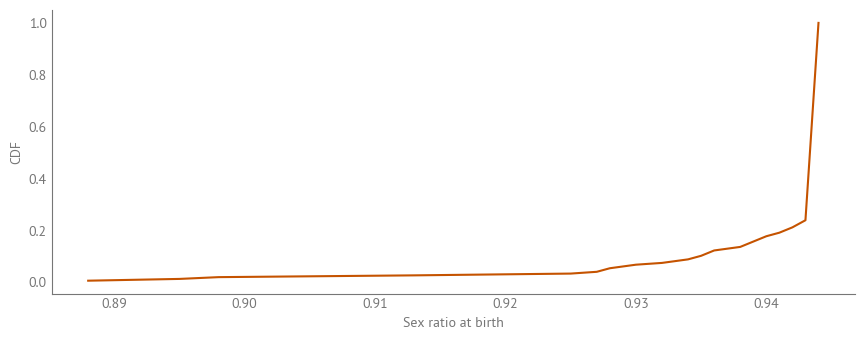

In [10]:
from empiricaldist import Cdf

cdf_score = Cdf.from_seq(df.loc[dinged, 'score'])
cdf_score.plot()
decorate(xlabel=xlabel, ylabel='CDF')

In [11]:
subset = df[dinged]
subset.sort_values("diff", ascending=False)

,country,page_number,score,rank,diff,left,right
code,,,,,,,
ALB,Albania,83,0.930,137,NaN,NaN,NaN
DZA,Algeria,85,0.944,1,NaN,NaN,NaN
AGO,Angola,87,0.944,1,NaN,NaN,NaN
ARG,Argentina,89,0.944,1,NaN,NaN,NaN
ARM,Armenia,91,0.913,143,NaN,NaN,NaN
...,...,...,...,...,...,...,...
UZB,Uzbekistan,365,0.925,142,NaN,NaN,NaN
VUT,Vanuatu,367,0.935,132,NaN,NaN,NaN
VNM,Vietnam,369,0.898,144,NaN,NaN,NaN


Without data, we have to accept the original scores as revised scores.

In [17]:
df['ratio'] = df['left'] / df['right']
df['ratio'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ratio, dtype: float64

In [18]:
df['revised_score'] = df['score']
df['revised_score'].describe()

count    146.000000
mean       0.941199
std        0.008304
min        0.888000
25%        0.944000
50%        0.944000
75%        0.944000
max        0.944000
Name: revised_score, dtype: float64

Here's the distribution of revised scores.

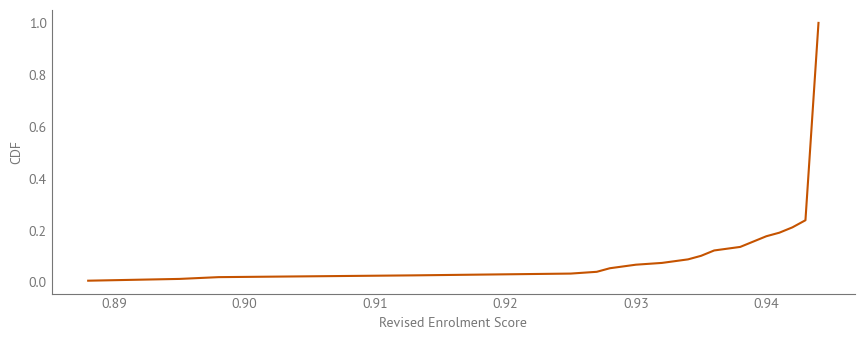

In [19]:
cdf_score = Cdf.from_seq(df['revised_score'])
cdf_score.plot()
decorate(xlabel='Revised Enrolment Score', ylabel='CDF')

Here's the distribution of revised scores, compare to the original.

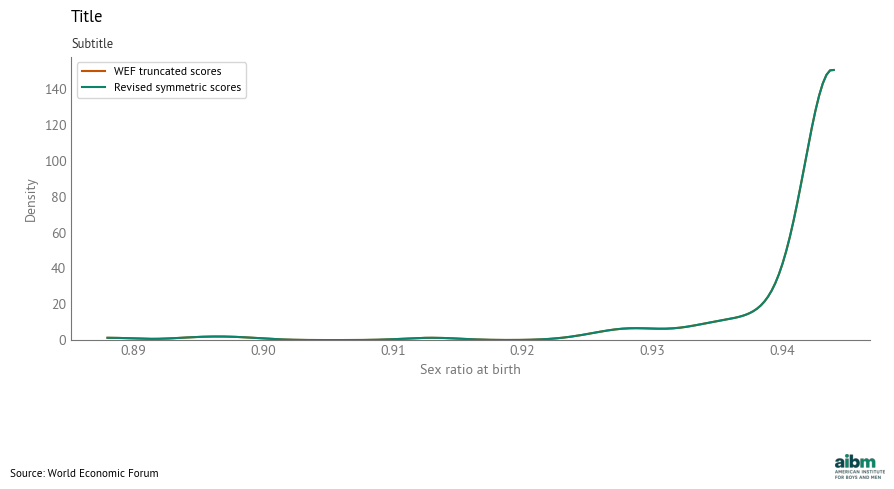

In [20]:
from utils import plot_score_distributions, add_title

plot_score_distributions(df, xlabel=xlabel)
add_title("Title",
          "Subtitle")

## Export the results

In [21]:
from utils import make_rank_table

table = make_rank_table(df)
table.to_csv("wef_sex_ratio_table.csv")
table.shape

(146, 6)

In [22]:
table['score'].describe()

count    146.000000
mean       0.941199
std        0.008304
min        0.888000
25%        0.944000
50%        0.944000
75%        0.944000
max        0.944000
Name: score, dtype: float64

In [24]:
from utils import make_weight_table

make_weight_table(table, 'sex ratio')

original             revised          
                std   inv std       std   inv std
sex ratio  0.008304  1.204205  0.008304  1.204205

## OECD countries

In [25]:
from utils import oecd_codes

df_oecd = df.loc[oecd_codes].sort_values(by='revised_score')

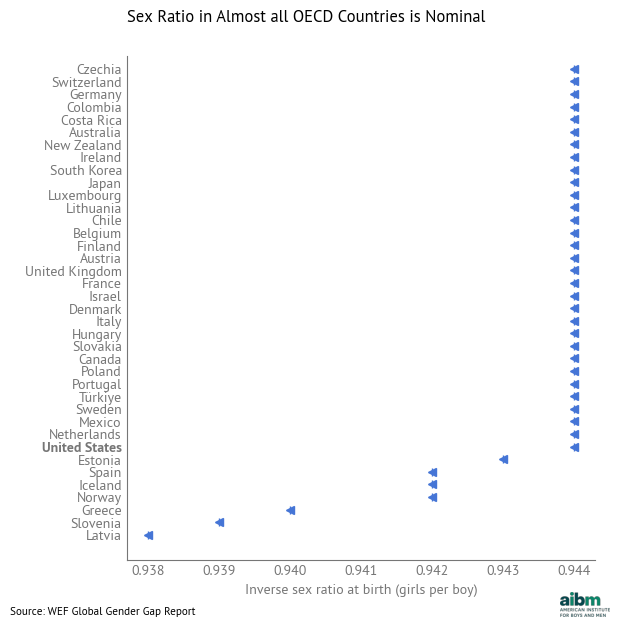

In [28]:
from utils import plot_revised_scores
from utils import add_title, add_subtext, add_logo

plot_revised_scores(df_oecd.sort_values(by='score', ascending=False))
decorate(xlabel='Inverse sex ratio at birth (girls per boy)')
add_title('Sex Ratio in Almost all OECD Countries is Nominal',
          '', y=1.02)
add_subtext('Source: WEF Global Gender Gap Report', y=-0.01)
logo = add_logo(location=(1.0, -0.01))

In [27]:
df.query("country == 'United States'")

,country,page_number,score,rank,diff,left,right,revised_score,revised_rank,ratio
code,,,,,,,,,,
USA,United States,361,0.944,1,NaN,NaN,NaN,0.944,1.0,NaN
